# Exercise 06: Vector Autoregressive (VAR) Models

**CBIOMES Workshop · Time Series in R**

In this notebook you will:

1. See why a univariate AR is not enough when species interact.
2. Fit a VAR model to a simulated predator-prey ecosystem.
3. Inspect the lag-coefficient matrices as heatmaps to read off interactions.
4. Compare AR and VAR for forecasting at multiple horizons.

## Setup

All packages already installed in the Docker container.

Expected files: `lotka_volterra_sim.csv` (Prey + 2 predators), `NPZ_Narragansett_Example.csv`.

In [1]:
library(vars)
library(ggplot2)

Loading required package: MASS

Loading required package: strucchange

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: urca

Loading required package: lmtest



## Background: What does VAR add?

A scalar AR(p) explains $y_t$ from its **own** past:
$$ y_t = \sum_{l=1}^{p} \phi_l\,y_{t-l} + \varepsilon_t. $$

A VAR(p) explains a **vector** $\mathbf{y}_t \in \mathbb{R}^k$ from **all** components' past:
$$ \mathbf{y}_t = \sum_{l=1}^{p} \mathbf{A}_l\,\mathbf{y}_{t-l} + \boldsymbol\varepsilon_t. $$

Each $\mathbf{A}_l$ is a $k \times k$ matrix. Off-diagonal entries are **cross-effects** — exactly what's missing from an AR.

---

## Part 1: Lotka–Volterra: prey + two predators

Run the two folling cells to load the data and get a first look at the data.

In [2]:
lv <- read.csv("lotka_volterra_sim.csv", check.names = FALSE)
head(lv)

,Prey,Pred1,Pred2
,<dbl>,<dbl>,<dbl>
1,10.0000000,5.0000000,3.0000000
2,0.8182410,4.3071803,2.6745693
3,0.2630020,1.7660712,1.3105212
4,0.2230086,0.6886352,0.6167451
5,0.2816800,0.2695721,0.2911611
6,0.4165866,0.1080761,0.1401110


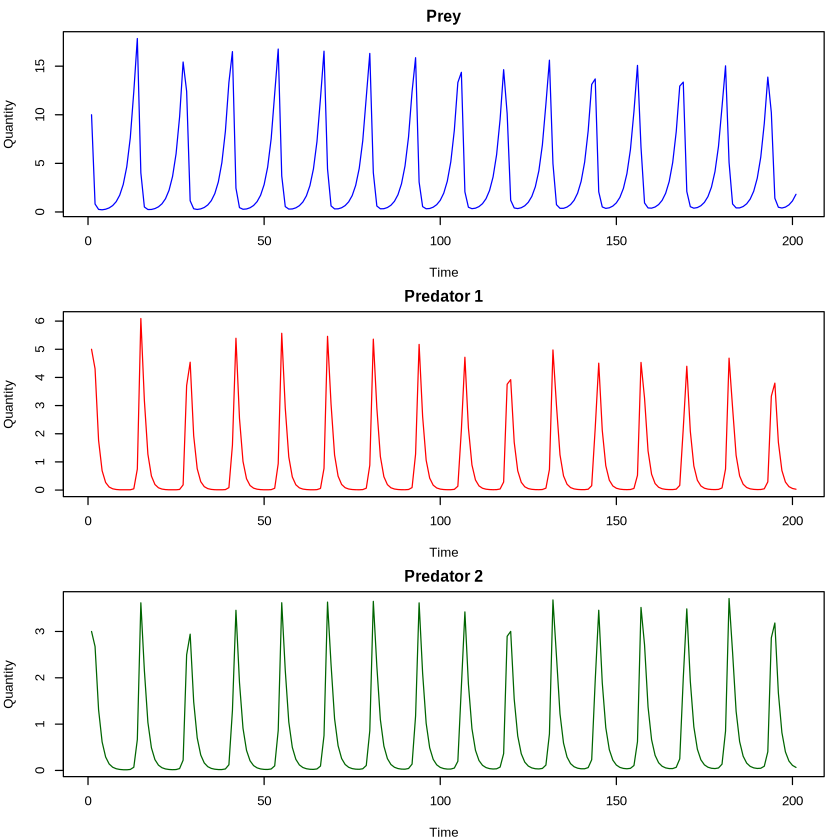

In [3]:
plot_times <- seq_len(nrow(lv))

par(mfrow = c(3, 1), mar = c(4, 4, 2, 1))
plot(plot_times, lv$Prey,  type = "l", col = "blue",
     main = "Prey",       xlab = "Time", ylab = "Quantity")
plot(plot_times, lv$Pred1, type = "l", col = "red",
     main = "Predator 1", xlab = "Time", ylab = "Quantity")
plot(plot_times, lv$Pred2, type = "l", col = "darkgreen",
     main = "Predator 2", xlab = "Time", ylab = "Quantity")
par(mfrow = c(1, 1))

**Discuss.** Do you see oscillatory predator–prey dynamics? Are the series visually correlated, with predator peaks lagging prey peaks?

---

## Part 2: Univariate AR baseline on Prey

Fit a AR(p) with 5 lags. Test if the residuals are white noise.

In [4]:
fit_ar <- ar(lv$Prey, method = "ols", order.max = 5)
cat("Selected lag p =", fit_ar$order, "\n\n")
cat("AR coefficients:\n"); print(fit_ar$ar)

lb_ar <- Box.test(fit_ar$resid, lag = 20, type = "Ljung-Box")
cat("\nLjung-Box p-value (AR residuals):", lb_ar$p.value, "\n")

Selected lag p = 5 

AR coefficients:
, , 1

            [,1]
[1,]  0.87516704
[2,] -0.42863766
[3,]  0.04179618
[4,] -0.02396244
[5,] -0.19773270


Ljung-Box p-value (AR residuals): 0 


**Reading.** A small Ljung-Box $p$-value tells us residuals are **not** white noise, the AR is missing structure. That structure is the predators' influence.

---

## Part 3: Fit a VAR with all three species

Fit a VAR with a maximum of 3 lags.

### Hints

- `VAR(data, p, type = "const")` from the `vars` package fits a VAR(p) with intercept.
- `coef(fit_var)$Prey` returns the Prey equation's coefficient table.

In [5]:
fit_var <- VAR(lv, p = 3, type = "const")
cat("VAR coefficients (Prey equation):\n")
print(coef(fit_var)$Prey)

VAR coefficients (Prey equation):
             Estimate Std. Error    t value     Pr(>|t|)
Prey.l1   0.971582335 0.15254955  6.3689625 1.425138e-09
Pred1.l1 -0.597448530 0.58858498 -1.0150591 3.113822e-01
Pred2.l1 -0.308174364 0.37362095 -0.8248316 4.105125e-01
Prey.l2  -0.251362499 0.21734787 -1.1564986 2.489447e-01
Pred1.l2  0.377820582 0.19891751  1.8993833 5.904522e-02
Pred2.l2 -0.130312196 0.10241177 -1.2724338 2.047905e-01
Prey.l3   0.154942593 0.13296926  1.1652512 2.453936e-01
Pred1.l3 -0.096493319 0.09893775 -0.9752933 3.306681e-01
Pred2.l3  0.034852159 0.05442122  0.6404148 5.226827e-01
const    -0.005753587 0.02928345 -0.1964791 8.444474e-01


Check the residuals for this case.

In [6]:
resids <- residuals(fit_var)
lb_var <- Box.test(resids[, "Prey"], lag = 20, type = "Ljung-Box")
cat("Ljung-Box p-value (VAR residuals, Prey):", lb_var$p.value, "\n")

Ljung-Box p-value (VAR residuals, Prey): 0 


---

## Part 4: Visualise the lag matrices

Use the following code to plot the following: For each lag $l$ we extract the $k \times k$ matrix $\mathbf{A}_l$ where row = response, column = predictor. Then plot as a heatmap.

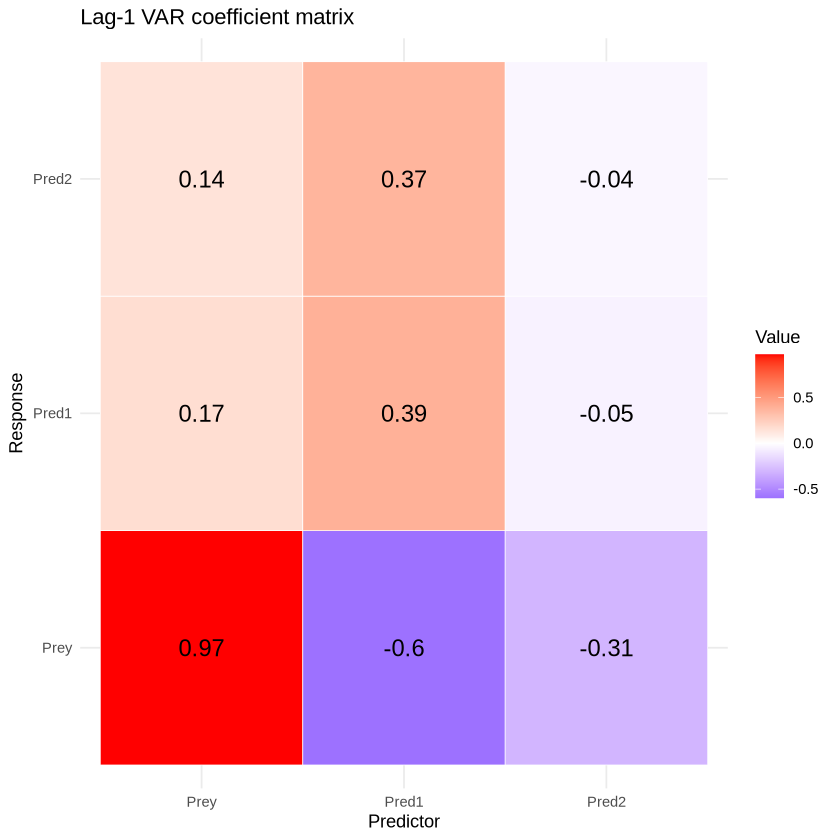

In [7]:
# Extract the 3x3 lag-1 matrix: rows = response, columns = predictor
k <- ncol(lv)
var_names <- colnames(lv)
A1 <- matrix(0, k, k, dimnames = list(var_names, var_names))
for (eq in var_names) {
    eq_coefs <- coef(fit_var)[[eq]]
    for (pred in var_names) {
        nm <- paste0(make.names(pred), ".l1")
        if (nm %in% rownames(eq_coefs)) {
            A1[eq, pred] <- eq_coefs[nm, "Estimate"]
        }
    }
}

# Heatmap with values
A1_df <- expand.grid(Response = var_names, Predictor = var_names)
A1_df$Value <- as.vector(A1)

ggplot(A1_df, aes(x = Predictor, y = Response, fill = Value)) +
    geom_tile(color = "white") +
    geom_text(aes(label = round(Value, 2)), size = 5) +
    scale_fill_gradient2(low = "blue", mid = "white", high = "red") +
    labs(title = "Lag-1 VAR coefficient matrix") +
    theme_minimal()

**How to read these heatmaps.**

- Diagonal = self-effects (autoregressive).
- Off-diagonal cell `(i, j)` = how strongly the past of $j$ pushes $i$ today.
- Red = positive, blue = negative.

For predator–prey systems, expect a **negative** Pred → Prey entry (predation suppresses prey) and a **positive** Prey → Pred entry (more prey ⇒ predators thrive).

### Discussion

- Why is a univariate AR insufficient for interacting species?
- What does VAR capture that AR cannot?
- When might you still prefer a simple AR? (small sample, want interpretability of one variable, exogenous-only modelling.)
- Why does VAR's advantage often **grow** at longer horizons?

### Common pitfalls

- Choosing `p` too high → not enough degrees of freedom (`k * p + 1` parameters per equation).
- Forgetting to align fitted values with observations (VAR's `fitted()` starts at row `p+1`).
- Ignoring stationarity — VAR assumes it. Run ADF/KPSS first if in doubt (Exercise 05).

---

## Bonus — VAR on the NPZ data

In [10]:
npz <- as.data.frame(read.csv("NPZ_Narragansett_Example.csv"))
fit_var_npz <- VAR(npz[, c("NO3", "P", "Z")], p = 3, type = "const")
summary(fit_var_npz)$varresult$Z


Call:
lm(formula = y ~ -1 + ., data = datamat)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.53091 -0.11861 -0.03696  0.06222  0.51152 

Coefficients:
       Estimate Std. Error t value Pr(>|t|)    
NO3.l1 -0.19496    0.15297  -1.275 0.203396    
P.l1   -0.51649    0.14014  -3.686 0.000267 ***
Z.l1   -0.11120    0.10828  -1.027 0.305217    
NO3.l2 -0.02277    0.09526  -0.239 0.811222    
P.l2   -0.04673    0.10125  -0.462 0.644711    
Z.l2   -0.04607    0.09011  -0.511 0.609486    
NO3.l3  0.06168    0.11356   0.543 0.587388    
P.l3   -0.35792    0.08046  -4.448 1.19e-05 ***
Z.l3    0.32121    0.10071   3.190 0.001564 ** 
const   0.24627    0.02219  11.100  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1974 on 324 degrees of freedom
Multiple R-squared:  0.4319,	Adjusted R-squared:  0.4161 
F-statistic: 27.36 on 9 and 324 DF,  p-value: < 2.2e-16


**Reading.** With a real-world ecological dataset the coefficients are often noisier and effects more subtle than in the simulated LV system, but the same workflow applies.

---

## Wrap-up

- Fit a VAR with `vars::VAR()`.
- Extract and interpret lag-coefficient matrices.
- Compare AR and VAR using both **fit** and **forecast** metrics.

Next: distinguishing **endogenous and exogenous** variables (Exercise 07).